# IFQ580 Machine Learning Assignment 1A
## Team 02H - Ananth Naidu, Alen James, Neville Doyle

In [249]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv("kick_1.csv")

C:\Users\anant\AppData\Local\Temp\ipykernel_23080\3605721652.py:1: DtypeWarning: Columns (0: IsOnlineSale) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("kick_1.csv")


In [3]:
df.head()

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
0,0,1253232000,18/09/2009 10:00,OTHER,2008.0,DODGE,RED,AUTO,2,Covers,...,12505,0.941783287,?,?,NC,7800,0.0,920.0,Yes,0
1,1,1253232000,18/09/2009 10:00,OTHER,2008.0,DODGE,RED,AUTO,2,Covers,...,10571,0.922618485,?,?,NC,7800,0.0,834.0,Yes,0
2,2,1253232000,18/09/2009 10:00,OTHER,2008.0,CHRYSLER,SILVER,AUTO,2,Covers,...,9932,0.935159082,?,?,NC,7800,0.0,834.0,Yes,0
3,3,1253232000,18/09/2009 10:00,OTHER,2008.0,CHEVROLET,RED,AUTO,2,Covers,...,8739,0.931456688,?,?,NC,6000,0.0,671.0,Yes,0
4,4,1253232000,18/09/2009 10:00,OTHER,2008.0,DODGE,SILVER,AUTO,2,Covers,...,9908,0.906943884,?,?,NC,7800,0.0,920.0,Yes,0


In [4]:
df.shape

(41476, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41476 entries, 0 to 41475
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   PurchaseID                         41476 non-null  int64  
 1   PurchaseTimestamp                  41476 non-null  int64  
 2   PurchaseDate                       41476 non-null  str    
 3   Auction                            41432 non-null  str    
 4   VehYear                            41432 non-null  float64
 5   Make                               41432 non-null  str    
 6   Color                              41432 non-null  str    
 7   Transmission                       41432 non-null  str    
 8   WheelTypeID                        41432 non-null  str    
 9   WheelType                          41380 non-null  str    
 10  VehOdo                             41432 non-null  float64
 11  Nationality                        41432 non-null  str    
 12  S

In [6]:
df.isnull().sum()

PurchaseID                             0
PurchaseTimestamp                      0
PurchaseDate                           0
Auction                               44
VehYear                               44
Make                                  44
Color                                 44
Transmission                          44
WheelTypeID                           44
WheelType                             96
VehOdo                                44
Nationality                           44
Size                                  44
TopThreeAmericanName                  44
MMRAcquisitionAuctionAveragePrice     60
MMRAcquisitionAuctionCleanPrice       47
MMRAcquisitionRetailAveragePrice      47
MMRAcquisitonRetailCleanPrice        149
MMRCurrentAuctionAveragePrice         47
MMRCurrentAuctionCleanPrice           47
MMRCurrentRetailAveragePrice          67
MMRCurrentRetailCleanPrice            67
MMRCurrentRetailRatio                360
PRIMEUNIT                             44
AUCGUART        

In [7]:
df[df["VehYear"].isnull()]

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [8]:
df[df["Auction"].isnull()]

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [9]:
(df == "?").sum()

PurchaseID                               0
PurchaseTimestamp                        0
PurchaseDate                             0
Auction                                  0
VehYear                                  0
Make                                     0
Color                                    6
Transmission                             6
WheelTypeID                           1775
WheelType                             1777
VehOdo                                   0
Nationality                              3
Size                                     3
TopThreeAmericanName                     3
MMRAcquisitionAuctionAveragePrice        7
MMRAcquisitionAuctionCleanPrice          7
MMRAcquisitionRetailAveragePrice         7
MMRAcquisitonRetailCleanPrice            7
MMRCurrentAuctionAveragePrice          184
MMRCurrentAuctionCleanPrice            184
MMRCurrentRetailAveragePrice           184
MMRCurrentRetailCleanPrice             184
MMRCurrentRetailRatio                    0
PRIMEUNIT  

In [10]:
df["PRIMEUNIT"].value_counts(dropna=False)

PRIMEUNIT
?      39634
NO      1764
NaN       44
YES       34
Name: count, dtype: int64

In [11]:
df["AUCGUART"].value_counts(dropna=False)

AUCGUART
?        39634
GREEN     1754
RED         44
NaN         44
Name: count, dtype: int64

In [12]:
df["WheelTypeID"].value_counts(dropna=False)

WheelTypeID
1      20426
2      18791
?       1775
3        437
NaN       44
0          3
Name: count, dtype: int64

In [13]:
df["WheelType"].value_counts(dropna=False)

WheelType
Alloy      20406
Covers     18761
?           1777
Special      436
NaN           96
Name: count, dtype: int64

In [14]:
pd.crosstab(df["WheelTypeID"], df["WheelType"], dropna=False)

WheelType,?,Alloy,Covers,Special,NaN
WheelTypeID,,,,,
0,3,0,0,0,0
1,0,20406,0,0,20
2,0,0,18761,0,30
3,0,0,0,436,1
?,1774,0,0,0,1
NaN,0,0,0,0,44


In [15]:
df["PurchaseID"].nunique()

41476

In [16]:
df["ForSale"].value_counts(dropna=False)

ForSale
Yes    27402
YES     8544
yes     5524
?          3
No         2
0          1
Name: count, dtype: int64

In [17]:
df["IsOnlineSale"].value_counts(dropna=False)

IsOnlineSale
 0.0    31368
 0       8572
 1.0      753
-1.0      601
 1        134
 NaN       44
 ?          2
 2.0        1
 4.0        1
Name: count, dtype: int64

In [18]:
df["Color"].value_counts(dropna=False)

Color
SILVER       8541
WHITE        6890
BLUE         5855
BLACK        4392
GREY         4248
RED          3661
GOLD         3059
GREEN        1796
MAROON       1039
BEIGE         894
ORANGE        255
BROWN         249
PURPLE        205
YELLOW        141
OTHER         136
NOT AVAIL      65
NaN            44
?               6
Name: count, dtype: int64

In [19]:
df["Transmission"].value_counts(dropna=False)

Transmission
AUTO      39930
MANUAL     1495
NaN          44
?             6
Manual        1
Name: count, dtype: int64

In [20]:
df["Nationality"].value_counts(dropna=False)

Nationality
AMERICAN          34616
OTHER ASIAN        4474
TOP LINE ASIAN     2110
USA                 125
OTHER               104
NaN                  44
?                     3
Name: count, dtype: int64

In [21]:
df["Size"].value_counts(dropna=False)

Size
MEDIUM         17540
LARGE           4968
MEDIUM SUV      4569
COMPACT         4035
VAN             3367
LARGE TRUCK     1897
SMALL SUV       1332
SPECIALTY        998
CROSSOVER        974
LARGE SUV        830
SMALL TRUCK      494
SPORTS           425
NaN               44
?                  3
Name: count, dtype: int64

In [22]:
df["TopThreeAmericanName"].value_counts(dropna=False)

TopThreeAmericanName
GM          14075
CHRYSLER    13627
FORD         7039
OTHER        6688
NaN            44
?               3
Name: count, dtype: int64

In [23]:
df["Make"].value_counts(dropna=False)

Make
CHEVROLET     9548
DODGE         7385
FORD          6458
CHRYSLER      5259
PONTIAC       2355
KIA           1337
SATURN        1245
NISSAN        1186
JEEP           985
HYUNDAI        957
SUZUKI         842
TOYOTA         664
MITSUBISHI     569
MAZDA          532
MERCURY        527
BUICK          413
GMC            351
HONDA          263
OLDSMOBILE     146
ISUZU           82
SCION           77
VOLKSWAGEN      73
LINCOLN         54
NaN             44
INFINITI        27
ACURA           19
MINI            19
CADILLAC        17
SUBARU          17
LEXUS           13
VOLVO           12
Name: count, dtype: int64

In [24]:
pd.crosstab(df["Make"], df["TopThreeAmericanName"], dropna=False)

TopThreeAmericanName,?,CHRYSLER,FORD,GM,OTHER,NaN
Make,,,,,,
ACURA,0,0,0,0,19,0
BUICK,0,0,0,413,0,0
CADILLAC,0,0,0,17,0,0
CHEVROLET,0,0,0,9548,0,0
CHRYSLER,0,5259,0,0,0,0
DODGE,0,7385,0,0,0,0
FORD,0,0,6458,0,0,0
GMC,0,0,0,351,0,0
HONDA,0,0,0,0,263,0


In [25]:
df["Auction"].value_counts(dropna=False)

Auction
MANHEIM    22168
ADESA      11086
OTHER       8178
NaN           44
Name: count, dtype: int64

In [26]:
df["VNST"].value_counts(dropna=False)

VNST
TX     9076
FL     5250
CO     3623
NC     3594
AZ     3383
CA     3268
OK     2595
SC     1662
TN     1471
GA     1287
VA     1093
MO      758
PA      700
NV      553
IN      486
MS      412
LA      349
NJ      317
NM      239
KY      230
AL      179
IL      165
UT      165
WV      137
WA      136
OR      136
NH       97
NaN      44
NE       26
OH       25
ID       14
NY        6
Name: count, dtype: int64

In [27]:
df["VehYear"].value_counts(dropna=False)

VehYear
2006.0    9630
2005.0    8682
2007.0    6514
2004.0    5792
2008.0    4177
2003.0    3554
2002.0    1879
2001.0     816
2009.0     387
NaN         44
2010.0       1
Name: count, dtype: int64

In [28]:
df["VehOdo"].value_counts(dropna=False)

VehOdo
NaN        44
74671.0     6
67464.0     6
71225.0     6
83962.0     6
           ..
74407.0     1
82563.0     1
65399.0     1
45234.0     1
66855.0     1
Name: count, Length: 28605, dtype: int64

In [29]:
df["VehOdo"].describe()

count     41432.000000
mean      71300.010427
std       14724.041171
min         577.000000
25%       61578.000000
50%       73128.500000
75%       82259.250000
max      480444.000000
Name: VehOdo, dtype: float64

In [30]:
df["VehOdo"].nlargest(10)

5        480444.0
8942     115717.0
28566    114184.0
22930    112056.0
23438    110119.0
1443     110071.0
10187    109848.0
33354    109728.0
20862    109662.0
22943    109564.0
Name: VehOdo, dtype: float64

In [31]:
df["VehBCost"].value_counts(dropna=False)

VehBCost
7500     459
6500     267
7800     259
7200     254
7000     247
        ... 
3590       1
3295       1
11580      1
10885      1
11945      1
Name: count, Length: 1870, dtype: int64

In [32]:
df[df["VehBCost"] == "?"]

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
1973,1973,1242086400,12/05/2009 10:00,MANHEIM,2006.0,LEXUS,BLACK,AUTO,1,Alloy,...,26164,0.891568567,YES,GREEN,FL,?,0.0,764.0,Yes,1
2529,2529,1256601600,27/10/2009 10:00,MANHEIM,2006.0,JEEP,BLACK,AUTO,1,Alloy,...,24396,0.888998196,?,?,CO,?,0.0,1583.0,Yes,1
4258,4258,1261958400,28/12/2009 10:00,MANHEIM,2008.0,PONTIAC,GREY,AUTO,1,Alloy,...,25060,0.969114126,?,?,VA,?,0.0,1121.0,Yes,1
6522,6522,1258675200,20/11/2009 10:00,MANHEIM,2006.0,INFINITI,OTHER,AUTO,1,Alloy,...,22120,0.908227848,?,?,NV,?,0.0,762.0,Yes,1
8250,8250,1274659200,24/05/2010 10:00,MANHEIM,2007.0,TOYOTA,MAROON,AUTO,1,Alloy,...,23285,0.920377926,?,?,AZ,?,0.0,522.0,Yes,1
19939,19939,1246406400,1/07/2009 10:00,MANHEIM,2008.0,TOYOTA,RED,AUTO,1,Alloy,...,26143,0.931377424,?,?,CO,?,0.0,588.0,Yes,1
20945,20945,1285286400,24/09/2010 10:00,OTHER,2008.0,MAZDA,BLUE,AUTO,1,Alloy,...,16516,0.899733592,NO,GREEN,NH,?,0.0,837.0,Yes,0
20953,20953,1285286400,24/09/2010 10:00,OTHER,2008.0,MAZDA,SILVER,MANUAL,1,Alloy,...,15952,0.905591775,?,?,NH,?,0.0,837.0,Yes,0
20958,20958,1285286400,24/09/2010 10:00,OTHER,2008.0,MAZDA,MAROON,AUTO,1,Alloy,...,14746,0.911297979,?,?,NH,?,0.0,837.0,Yes,0
21211,21211,1276473600,14/06/2010 10:00,OTHER,2006.0,SCION,MAROON,AUTO,2,Covers,...,12857,0.855409505,?,?,WV,?,0.0,594.0,Yes,0


In [33]:
df["WarrantyCost"].describe()

count    41432.000000
mean      1273.050758
std        599.188662
min        462.000000
25%        834.000000
50%       1155.000000
75%       1623.000000
max       7498.000000
Name: WarrantyCost, dtype: float64

In [34]:
df["MMRAcquisitionAuctionAveragePrice"].value_counts(dropna=False)

MMRAcquisitionAuctionAveragePrice
0        502
5480     205
6311      96
7811      79
7644      74
        ... 
10797      1
1449       1
9842       1
1996       1
7535       1
Name: count, Length: 9272, dtype: int64

In [35]:
df[df["MMRAcquisitionAuctionAveragePrice"] == "?"]

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
4878,4878,1252454400,9/09/2009 10:00,MANHEIM,2003.0,FORD,GREEN,AUTO,1,Alloy,...,?,#VALUE!,?,?,TX,7185,0.0,1209.0,Yes,0
5006,5006,1255478400,14/10/2009 10:00,MANHEIM,2007.0,JEEP,SILVER,AUTO,1,Alloy,...,?,#VALUE!,?,?,TX,10750,0.0,1801.0,Yes,0
20558,20558,1279670400,21/07/2010 10:00,MANHEIM,2004.0,NISSAN,GREY,AUTO,1,Alloy,...,?,#VALUE!,?,?,TX,9335,0.0,1003.0,Yes,0
33424,33424,1246924800,7/07/2009 10:00,MANHEIM,2003.0,FORD,WHITE,AUTO,1,Alloy,...,?,#VALUE!,?,?,TX,8655,0,1103.0,YES,0
35503,35503,1286323200,6/10/2010 10:00,OTHER,2007.0,DODGE,BLUE,AUTO,1,Alloy,...,?,#VALUE!,NO,GREEN,KY,10210,0,1918.0,YES,0
37037,37037,1282176000,19/08/2010 10:00,ADESA,2007.0,DODGE,WHITE,AUTO,1,Alloy,...,?,#VALUE!,?,?,CO,11845,0,1623.0,YES,0
38215,38215,1251849600,2/09/2009 10:00,ADESA,2007.0,GMC,BLACK,AUTO,2,Covers,...,?,#VALUE!,?,?,AZ,7370,0,1373.0,YES,0


In [36]:
df["MMRAcquisitionAuctionAveragePrice"].value_counts(dropna=False).head(10)

MMRAcquisitionAuctionAveragePrice
0       502
5480    205
6311     96
7811     79
7644     74
7991     72
5569     71
4573     67
7245     62
NaN      60
Name: count, dtype: int64

In [37]:
[col for col in df.columns if "MMRAcquisition" in col]

['MMRAcquisitionAuctionAveragePrice',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice']

In [38]:
df.loc[df["MMRAcquisitionAuctionAveragePrice"] == "0", ["MMRAcquisitionAuctionAveragePrice", "MMRAcquisitionAuctionCleanPrice", "MMRAcquisitionRetailAveragePrice"]].head(20)

,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice
516,0,0,0
517,0,0,0
631,0,0,0
632,0,0,0
633,0,0,0
896,0,1,0
1017,0,1,0
1040,0,1,0
1070,0,1,0
1078,0,1,0


In [39]:
df["MMRAcquisitionAuctionAveragePrice"].value_counts().head(10)

MMRAcquisitionAuctionAveragePrice
0       502
5480    205
6311     96
7811     79
7644     74
7991     72
5569     71
4573     67
7245     62
6858     57
Name: count, dtype: int64

In [40]:
df["MMRAcquisitionAuctionCleanPrice"].value_counts().head(10)

MMRAcquisitionAuctionCleanPrice
0       415
6461    207
7450    100
1        87
8258     81
8892     74
6584     67
8449     63
7837     59
9044     58
Name: count, dtype: int64

In [41]:
df["MMRAcquisitionRetailAveragePrice"].value_counts().head(10)

MMRAcquisitionRetailAveragePrice
0        502
6418     206
7316      96
11114     81
8756      77
6515      68
5439      59
7907      58
9097      58
11882     58
Name: count, dtype: int64

In [42]:
df["MMRCurrentAuctionAveragePrice"].value_counts().head(10)

MMRCurrentAuctionAveragePrice
0       287
?       184
5480    160
6311     78
7269     75
8186     71
8033     66
7644     65
5569     59
6966     54
Name: count, dtype: int64

In [43]:
df["MMRCurrentAuctionCleanPrice"].value_counts().head(10)

MMRCurrentAuctionCleanPrice
0       206
?       184
6461    163
1        81
7450     77
8892     66
7898     58
8107     56
6584     54
9279     54
Name: count, dtype: int64

In [44]:
df["MMRCurrentRetailAveragePrice"].value_counts().head(10)

MMRCurrentRetailAveragePrice
0        287
?        184
6418     157
7316      77
8756      65
10834     57
11674     55
6515      53
7907      49
9352      47
Name: count, dtype: int64

In [45]:
df["MMRCurrentRetailCleanPrice"].value_counts().head(10)

MMRCurrentRetailCleanPrice
0        287
?        184
7478     161
8546      75
10103     65
12387     59
7611      57
11413     54
11706     52
10268     48
Name: count, dtype: int64

In [46]:
df["MMRCurrentRetailRatio"].describe()

count       41116
unique      25870
top       #VALUE!
freq          178
Name: MMRCurrentRetailRatio, dtype: object

In [47]:
df["MMRCurrentRetailRatio"].value_counts(dropna=False).head(10)

MMRCurrentRetailRatio
NaN            360
#VALUE!        178
0.858250869    156
0.856073017     74
0.866673265     62
0.949268378     53
0.855997898     52
0.907493781     48
0.910790806     46
0.854256698     43
Name: count, dtype: int64

In [48]:
df.loc[0, ["MMRAcquisitionRetailAveragePrice", "MMRCurrentRetailAveragePrice", "MMRCurrentRetailRatio"]]

MMRAcquisitionRetailAveragePrice           9751
MMRCurrentRetailAveragePrice              11777
MMRCurrentRetailRatio               0.941783287
Name: 0, dtype: str

In [49]:
df[["PurchaseTimestamp", "PurchaseDate"]].head(10)

,PurchaseTimestamp,PurchaseDate
0,1253232000,18/09/2009 10:00
1,1253232000,18/09/2009 10:00
2,1253232000,18/09/2009 10:00
3,1253232000,18/09/2009 10:00
4,1253232000,18/09/2009 10:00
5,1253232000,18/09/2009 10:00
6,1253232000,18/09/2009 10:00
7,1253232000,18/09/2009 10:00
8,1253232000,18/09/2009 10:00
9,1253232000,18/09/2009 10:00


In [50]:
df[["PurchaseTimestamp", "PurchaseDate"]].drop_duplicates().head(20)

,PurchaseTimestamp,PurchaseDate
0,1253232000,18/09/2009 10:00
22,1254182400,29/09/2009 10:00
26,1254700800,5/10/2009 10:00
35,1254873600,7/10/2009 10:00
36,1254960000,8/10/2009 10:00
75,1255305600,12/10/2009 10:00
89,1255392000,13/10/2009 10:00
91,1255478400,14/10/2009 10:00
93,1255910400,19/10/2009 10:00
107,1255996800,20/10/2009 10:00


In [51]:
df["IsBadBuy"].value_counts()

IsBadBuy
0    36105
1     5371
Name: count, dtype: int64

In [52]:
df[df["Auction"].isna()].shape

(44, 31)

In [53]:
df_processed = df.dropna(subset=["Auction"]).copy()

In [54]:
df_processed.shape

(41432, 31)

In [55]:
df_processed = df_processed.drop(columns=["PurchaseID", "PurchaseTimestamp", "WheelTypeID", "TopThreeAmericanName", "PRIMEUNIT", "AUCGUART", "ForSale"])

In [56]:
df_processed.shape

(41432, 24)

In [57]:
df_processed["Transmission"] = df_processed["Transmission"].str.upper()

In [58]:
df_processed["Transmission"].value_counts(dropna=False)

Transmission
AUTO      39930
MANUAL     1496
?             6
Name: count, dtype: int64

In [59]:
df_processed["Transmission"] = df_processed["Transmission"].replace("?", "UNKNOWN")

In [60]:
df_processed["Transmission"].value_counts(dropna=False)

Transmission
AUTO       39930
MANUAL      1496
UNKNOWN        6
Name: count, dtype: int64

In [61]:
df_processed["Color"] = df_processed["Color"].replace(["NOT AVAIL", "?"], "UNKNOWN")

In [62]:
df_processed["Color"].value_counts(dropna=False)

Color
SILVER     8541
WHITE      6890
BLUE       5855
BLACK      4392
GREY       4248
RED        3661
GOLD       3059
GREEN      1796
MAROON     1039
BEIGE       894
ORANGE      255
BROWN       249
PURPLE      205
YELLOW      141
OTHER       136
UNKNOWN      71
Name: count, dtype: int64

In [63]:
df_processed["Nationality"] = df_processed["Nationality"].replace("?", "UNKNOWN")

In [64]:
df_processed["Nationality"].value_counts(dropna=False)

Nationality
AMERICAN          34616
OTHER ASIAN        4474
TOP LINE ASIAN     2110
USA                 125
OTHER               104
UNKNOWN               3
Name: count, dtype: int64

In [65]:
df_processed["Size"] = df_processed["Size"].replace("?", "UNKNOWN")

In [66]:
df_processed["Size"].value_counts(dropna=False)

Size
MEDIUM         17540
LARGE           4968
MEDIUM SUV      4569
COMPACT         4035
VAN             3367
LARGE TRUCK     1897
SMALL SUV       1332
SPECIALTY        998
CROSSOVER        974
LARGE SUV        830
SMALL TRUCK      494
SPORTS           425
UNKNOWN            3
Name: count, dtype: int64

In [67]:
df_processed["WheelType"] = df_processed["WheelType"].replace("?", "UNKNOWN")
df_processed["WheelType"] = df_processed["WheelType"].fillna("UNKNOWN")

In [68]:
df_processed["WheelType"].value_counts(dropna=False)

WheelType
Alloy      20406
Covers     18761
UNKNOWN     1829
Special      436
Name: count, dtype: int64

In [69]:
df_processed["IsOnlineSale"].value_counts(dropna=False)

IsOnlineSale
 0.0    31368
 0       8572
 1.0      753
-1.0      601
 1        134
 ?          2
 2.0        1
 4.0        1
Name: count, dtype: int64

In [70]:
df[df["IsOnlineSale"] == -1.0].head()

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
86,86,1255305600,12/10/2009 10:00,OTHER,2008.0,CHRYSLER,SILVER,AUTO,2,Covers,...,10949,0.948214449,?,?,TX,6500,-1.0,975.0,Yes,0
112,112,1256515200,26/10/2009 10:00,OTHER,2008.0,CHRYSLER,RED,AUTO,2,Covers,...,10807,0.945960951,?,?,TX,6500,-1.0,975.0,Yes,0
273,273,1275436800,2/06/2010 10:00,OTHER,2005.0,DODGE,MAROON,AUTO,1,Alloy,...,13776,0.793263647,?,?,TX,8725,-1.0,1506.0,Yes,0
440,440,1252022400,4/09/2009 10:00,OTHER,2002.0,PONTIAC,RED,AUTO,2,Covers,...,6906,0.738633073,?,?,SC,3300,-1.0,1543.0,Yes,0
598,598,1279238400,16/07/2010 10:00,OTHER,2003.0,TOYOTA,BLUE,MANUAL,2,Covers,...,8569,0.824600303,?,?,SC,5400,-1.0,869.0,Yes,0


In [71]:
df_processed["IsOnlineSale"] = pd.to_numeric(df_processed["IsOnlineSale"], errors="coerce")
df_processed["IsOnlineSale"] = df_processed["IsOnlineSale"].replace([-1, 2, 4], np.nan)

In [72]:
df_processed["IsOnlineSale"].value_counts(dropna=False)

IsOnlineSale
0.0    39940
1.0      887
NaN      605
Name: count, dtype: int64

In [73]:
df_processed["IsOnlineSale"] = df_processed["IsOnlineSale"].fillna(0)

In [74]:
df_processed["IsOnlineSale"].value_counts(dropna=False)

IsOnlineSale
0.0    40545
1.0      887
Name: count, dtype: int64

In [75]:
df_processed["VehBCost"] = pd.to_numeric(df_processed["VehBCost"], errors="coerce")

In [76]:
df_processed["VehBCost"].isna().sum()

np.int64(29)

In [77]:
df_processed["VehBCost"].describe()

count    41403.000000
mean      6733.107867
std       1771.737200
min        225.000000
25%       5440.000000
50%       6710.000000
75%       7900.000000
max      45469.000000
Name: VehBCost, dtype: float64

In [78]:
df_processed["VehBCost"] = df_processed["VehBCost"].fillna(df_processed["VehBCost"].median())

In [79]:
df_processed["VehBCost"].isna().sum()

np.int64(0)

In [80]:
df_processed["MMRAcquisitionAuctionAveragePrice"] = pd.to_numeric(df_processed["MMRAcquisitionAuctionAveragePrice"], errors="coerce")

In [81]:
df_processed["MMRAcquisitionAuctionAveragePrice"].isna().sum()

np.int64(23)

In [82]:
(df_processed["MMRAcquisitionAuctionAveragePrice"] == 0).sum()

np.int64(502)

In [83]:
df_processed["MMRAcquisitionAuctionAveragePrice"] = df_processed["MMRAcquisitionAuctionAveragePrice"].replace(0, np.nan)

In [84]:
df_processed["MMRAcquisitionAuctionAveragePrice"].isna().sum()

np.int64(525)

In [85]:
df_processed["MMRAcquisitionAuctionAveragePrice"].describe()

count    40907.000000
mean      6210.297675
std       2400.927399
min        884.000000
25%       4339.000000
50%       6150.000000
75%       7805.500000
max      33543.000000
Name: MMRAcquisitionAuctionAveragePrice, dtype: float64

In [86]:
df_processed["MMRAcquisitionAuctionAveragePrice"] = df_processed["MMRAcquisitionAuctionAveragePrice"].fillna(df_processed["MMRAcquisitionAuctionAveragePrice"].median())

In [87]:
df_processed["MMRAcquisitionAuctionAveragePrice"].isna().sum()

np.int64(0)

In [88]:
df_processed["MMRAcquisitionAuctionCleanPrice"] = pd.to_numeric(df_processed["MMRAcquisitionAuctionCleanPrice"], errors="coerce")

In [89]:
df_processed["MMRAcquisitionAuctionCleanPrice"].isna().sum()

np.int64(10)

In [90]:
df_processed["MMRAcquisitionAuctionCleanPrice"] = df_processed["MMRAcquisitionAuctionCleanPrice"].replace([0, 1], np.nan)

In [91]:
df_processed["MMRAcquisitionAuctionCleanPrice"].isna().sum()

np.int64(512)

In [92]:
df_processed["MMRAcquisitionAuctionCleanPrice"].describe()

count    40920.000000
mean      7465.596408
std       2634.971537
min       1076.000000
25%       5480.000000
50%       7357.000000
75%       9036.250000
max      36701.000000
Name: MMRAcquisitionAuctionCleanPrice, dtype: float64

In [93]:
df_processed["MMRAcquisitionAuctionCleanPrice"] = df_processed["MMRAcquisitionAuctionCleanPrice"].fillna(df_processed["MMRAcquisitionAuctionCleanPrice"].median())

In [94]:
df_processed["MMRAcquisitionAuctionCleanPrice"].isna().sum()

np.int64(0)

In [95]:
df_processed["MMRAcquisitionRetailAveragePrice"] = pd.to_numeric(df_processed["MMRAcquisitionRetailAveragePrice"], errors="coerce")

In [96]:
df_processed["MMRAcquisitionRetailAveragePrice"].isna().sum()

np.int64(10)

In [97]:
df_processed["MMRAcquisitionRetailAveragePrice"] = df_processed["MMRAcquisitionRetailAveragePrice"].replace(0, np.nan)

In [98]:
df_processed["MMRAcquisitionRetailAveragePrice"].isna().sum()

np.int64(512)

In [99]:
df_processed["MMRAcquisitionRetailAveragePrice"].describe()

count    40920.000000
mean      8548.114125
std       3046.794378
min       1455.000000
25%       6304.000000
50%       8437.500000
75%      10624.000000
max      36726.000000
Name: MMRAcquisitionRetailAveragePrice, dtype: float64

In [100]:
df_processed["MMRAcquisitionRetailAveragePrice"] = df_processed["MMRAcquisitionRetailAveragePrice"].fillna(df_processed["MMRAcquisitionRetailAveragePrice"].median())

In [101]:
df_processed["MMRAcquisitionRetailAveragePrice"].isna().sum()

np.int64(0)

In [102]:
df_processed["MMRCurrentAuctionAveragePrice"] = pd.to_numeric(df_processed["MMRCurrentAuctionAveragePrice"], errors="coerce")

In [103]:
df_processed["MMRCurrentAuctionAveragePrice"].isna().sum()

np.int64(187)

In [104]:
df_processed["MMRCurrentAuctionAveragePrice"] = df_processed["MMRCurrentAuctionAveragePrice"].replace(0, np.nan)

In [105]:
df_processed["MMRCurrentAuctionAveragePrice"].isna().sum()

np.int64(474)

In [106]:
df_processed["MMRCurrentAuctionAveragePrice"].describe()

count    40958.000000
mean      6190.048415
std       2399.615073
min        430.000000
25%       4328.000000
50%       6101.500000
75%       7764.000000
max      33369.000000
Name: MMRCurrentAuctionAveragePrice, dtype: float64

In [107]:
df_processed["MMRCurrentAuctionAveragePrice"] = df_processed["MMRCurrentAuctionAveragePrice"].fillna(df_processed["MMRCurrentAuctionAveragePrice"].median())

In [108]:
df_processed["MMRCurrentAuctionAveragePrice"].isna().sum()

np.int64(0)

In [109]:
df_processed["MMRCurrentAuctionCleanPrice"] = pd.to_numeric(df_processed["MMRCurrentAuctionCleanPrice"], errors="coerce")

In [110]:
df_processed["MMRCurrentAuctionCleanPrice"].isna().sum()

np.int64(187)

In [111]:
df_processed["MMRCurrentAuctionCleanPrice"] = df_processed["MMRCurrentAuctionCleanPrice"].replace([0, 1], np.nan)

In [112]:
df_processed["MMRCurrentAuctionCleanPrice"].isna().sum()

np.int64(474)

In [113]:
df_processed["MMRCurrentAuctionCleanPrice"].describe()

count    40958.000000
mean      7453.039064
std       2632.214907
min        651.000000
25%       5480.000000
50%       7347.000000
75%       9033.000000
max      36478.000000
Name: MMRCurrentAuctionCleanPrice, dtype: float64

In [114]:
df_processed["MMRCurrentAuctionCleanPrice"] = df_processed["MMRCurrentAuctionCleanPrice"].fillna(df_processed["MMRCurrentAuctionCleanPrice"].median())

In [115]:
df_processed["MMRCurrentAuctionCleanPrice"].isna().sum()

np.int64(0)

In [116]:
df_processed["MMRCurrentRetailAveragePrice"] = pd.to_numeric(df_processed["MMRCurrentRetailAveragePrice"], errors="coerce")

In [117]:
df_processed["MMRCurrentRetailAveragePrice"].isna().sum()

np.int64(207)

In [118]:
df_processed["MMRCurrentRetailAveragePrice"] = df_processed["MMRCurrentRetailAveragePrice"].replace(0, np.nan)

In [119]:
df_processed["MMRCurrentRetailAveragePrice"].isna().sum()

np.int64(494)

In [120]:
df_processed["MMRCurrentRetailAveragePrice"].describe()

count    40938.000000
mean      8826.060018
std       3027.803136
min        964.000000
25%       6570.000000
50%       8747.000000
75%      10934.000000
max      36539.000000
Name: MMRCurrentRetailAveragePrice, dtype: float64

In [121]:
df_processed["MMRCurrentRetailAveragePrice"] = df_processed["MMRCurrentRetailAveragePrice"].fillna(df_processed["MMRCurrentRetailAveragePrice"].median())

In [122]:
df_processed["MMRCurrentRetailAveragePrice"].isna().sum()

np.int64(0)

In [123]:
df_processed["MMRCurrentRetailCleanPrice"] = pd.to_numeric(df_processed["MMRCurrentRetailCleanPrice"], errors="coerce")

In [124]:
df_processed["MMRCurrentRetailCleanPrice"].isna().sum()

np.int64(207)

In [125]:
df_processed["MMRCurrentRetailCleanPrice"] = df_processed["MMRCurrentRetailCleanPrice"].replace(0, np.nan)

In [126]:
df_processed["MMRCurrentRetailCleanPrice"].isna().sum()

np.int64(494)

In [127]:
df_processed["MMRCurrentRetailCleanPrice"].describe()

count    40938.000000
mean     10200.470907
std       3221.861128
min       1203.000000
25%       7825.250000
50%      10110.000000
75%      12309.000000
max      39896.000000
Name: MMRCurrentRetailCleanPrice, dtype: float64

In [128]:
df_processed["MMRCurrentRetailCleanPrice"] = df_processed["MMRCurrentRetailCleanPrice"].fillna(df_processed["MMRCurrentRetailCleanPrice"].median())

In [129]:
df_processed["MMRCurrentRetailCleanPrice"].isna().sum()

np.int64(0)

In [130]:
df_processed["MMRCurrentRetailRatio"] = pd.to_numeric(df_processed["MMRCurrentRetailRatio"], errors="coerce")

In [131]:
df_processed["MMRCurrentRetailRatio"].isna().sum()

np.int64(494)

In [132]:
df_processed["MMRCurrentRetailRatio"].describe()

count    40938.000000
mean         0.856965
std          0.051371
min          0.358071
25%          0.827066
50%          0.860743
75%          0.892289
max          1.000000
Name: MMRCurrentRetailRatio, dtype: float64

In [133]:
df_processed["MMRCurrentRetailRatio"] = df_processed["MMRCurrentRetailRatio"].fillna(df_processed["MMRCurrentRetailRatio"].median())

In [134]:
df_processed["MMRCurrentRetailRatio"].isna().sum()

np.int64(0)

In [135]:
df_processed.isnull().sum()

PurchaseDate                           0
Auction                                0
VehYear                                0
Make                                   0
Color                                  0
Transmission                           0
WheelType                              0
VehOdo                                 0
Nationality                            0
Size                                   0
MMRAcquisitionAuctionAveragePrice      0
MMRAcquisitionAuctionCleanPrice        0
MMRAcquisitionRetailAveragePrice       0
MMRAcquisitonRetailCleanPrice        105
MMRCurrentAuctionAveragePrice          0
MMRCurrentAuctionCleanPrice            0
MMRCurrentRetailAveragePrice           0
MMRCurrentRetailCleanPrice             0
MMRCurrentRetailRatio                  0
VNST                                   0
VehBCost                               0
IsOnlineSale                           0
WarrantyCost                           0
IsBadBuy                               0
dtype: int64

In [136]:
df_processed["MMRAcquisitonRetailCleanPrice"].describe()

count     41327
unique    11583
top           0
freq        501
Name: MMRAcquisitonRetailCleanPrice, dtype: object

In [137]:
df_processed["MMRAcquisitonRetailCleanPrice"] = pd.to_numeric(df_processed["MMRAcquisitonRetailCleanPrice"], errors="coerce")

In [138]:
df_processed["MMRAcquisitonRetailCleanPrice"].isna().sum()

np.int64(112)

In [139]:
df_processed["MMRAcquisitonRetailCleanPrice"] = df_processed["MMRAcquisitonRetailCleanPrice"].replace(0, np.nan)

In [140]:
df_processed["MMRAcquisitonRetailCleanPrice"].isna().sum()

np.int64(613)

In [141]:
df_processed["MMRAcquisitonRetailCleanPrice"].describe()

count    40819.000000
mean      9918.175947
std       3243.319415
min       1662.000000
25%       7524.000000
50%       9777.000000
75%      12067.000000
max      40137.000000
Name: MMRAcquisitonRetailCleanPrice, dtype: float64

In [142]:
df_processed["MMRAcquisitonRetailCleanPrice"] = df_processed["MMRAcquisitonRetailCleanPrice"].fillna(df_processed["MMRAcquisitonRetailCleanPrice"].median())

In [143]:
df_processed["MMRAcquisitonRetailCleanPrice"].isna().sum()

np.int64(0)

In [144]:
df_processed.isnull().sum()

PurchaseDate                         0
Auction                              0
VehYear                              0
Make                                 0
Color                                0
Transmission                         0
WheelType                            0
VehOdo                               0
Nationality                          0
Size                                 0
MMRAcquisitionAuctionAveragePrice    0
MMRAcquisitionAuctionCleanPrice      0
MMRAcquisitionRetailAveragePrice     0
MMRAcquisitonRetailCleanPrice        0
MMRCurrentAuctionAveragePrice        0
MMRCurrentAuctionCleanPrice          0
MMRCurrentRetailAveragePrice         0
MMRCurrentRetailCleanPrice           0
MMRCurrentRetailRatio                0
VNST                                 0
VehBCost                             0
IsOnlineSale                         0
WarrantyCost                         0
IsBadBuy                             0
dtype: int64

In [145]:
df_processed.shape

(41432, 24)

In [146]:
df_processed["IsBadBuy"].value_counts()

IsBadBuy
0    36067
1     5365
Name: count, dtype: int64

In [147]:
df_processed.dtypes

PurchaseDate                             str
Auction                                  str
VehYear                              float64
Make                                     str
Color                                    str
Transmission                             str
WheelType                                str
VehOdo                               float64
Nationality                              str
Size                                     str
MMRAcquisitionAuctionAveragePrice    float64
MMRAcquisitionAuctionCleanPrice      float64
MMRAcquisitionRetailAveragePrice     float64
MMRAcquisitonRetailCleanPrice        float64
MMRCurrentAuctionAveragePrice        float64
MMRCurrentAuctionCleanPrice          float64
MMRCurrentRetailAveragePrice         float64
MMRCurrentRetailCleanPrice           float64
MMRCurrentRetailRatio                float64
VNST                                     str
VehBCost                             float64
IsOnlineSale                         float64
WarrantyCo

In [148]:
df_processed["PurchaseDate"] = pd.to_datetime(df_processed["PurchaseDate"], dayfirst=True)

In [149]:
df_processed.dtypes

PurchaseDate                         datetime64[us]
Auction                                         str
VehYear                                     float64
Make                                            str
Color                                           str
Transmission                                    str
WheelType                                       str
VehOdo                                      float64
Nationality                                     str
Size                                            str
MMRAcquisitionAuctionAveragePrice           float64
MMRAcquisitionAuctionCleanPrice             float64
MMRAcquisitionRetailAveragePrice            float64
MMRAcquisitonRetailCleanPrice               float64
MMRCurrentAuctionAveragePrice               float64
MMRCurrentAuctionCleanPrice                 float64
MMRCurrentRetailAveragePrice                float64
MMRCurrentRetailCleanPrice                  float64
MMRCurrentRetailRatio                       float64
VNST        

In [150]:
df_model = df_processed.drop(["PurchaseDate"], axis=1).copy()

In [151]:
df_model = pd.get_dummies(df_model)

In [152]:
df_model.shape

(41432, 121)

# Obtain the target values

In [153]:
y = df_model["IsBadBuy"].values

# Remove the target from the features

In [154]:
X = df_model.drop(["IsBadBuy"], axis=1)

# Save feature names for later interpretation

In [155]:
feature_names = X.columns

# Convert features to a numpy array

In [156]:
X = X.values

# Set random state and test set size

In [157]:
random_state = 10
test_set_size = 0.3

# Split data into training and testing sets

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_set_size,
    random_state=random_state,
    stratify=y
)

In [159]:
print("Size of X_train:", len(X_train))
print("Size of y_train:", len(y_train))
print("Size of X_test:", len(X_test))
print("Size of y_test:", len(y_test))

Size of X_train: 29002
Size of y_train: 29002
Size of X_test: 12430
Size of y_test: 12430


In [160]:
print("Training proportions:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest proportions:")
print(pd.Series(y_test).value_counts(normalize=True))

Training proportions:
0    0.870526
1    0.129474
Name: proportion, dtype: float64

Test proportions:
0    0.870475
1    0.129525
Name: proportion, dtype: float64


# Default Decision Tree

In [161]:
# Create the default decision tree
model_default = DecisionTreeClassifier(random_state=random_state)

# Train the decision tree
model_default.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [162]:
# Examine the model parameters and number of leaves
print("Model parameters:")
print(model_default.get_params())

Model parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}


In [163]:
# Calculate training and test accuracy
train_accuracy = model_default.score(X_train, y_train)
test_accuracy = model_default.score(X_test, y_test)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 1.0
Test accuracy: 0.8178600160901046


In [164]:
# Examine the size of the default decision tree
node_count = model_default.tree_.node_count
leaf_count = model_default.get_n_leaves()

print("Number of nodes:", node_count)
print("Number of leaves:", leaf_count)

Number of nodes: 6303
Number of leaves: 3152


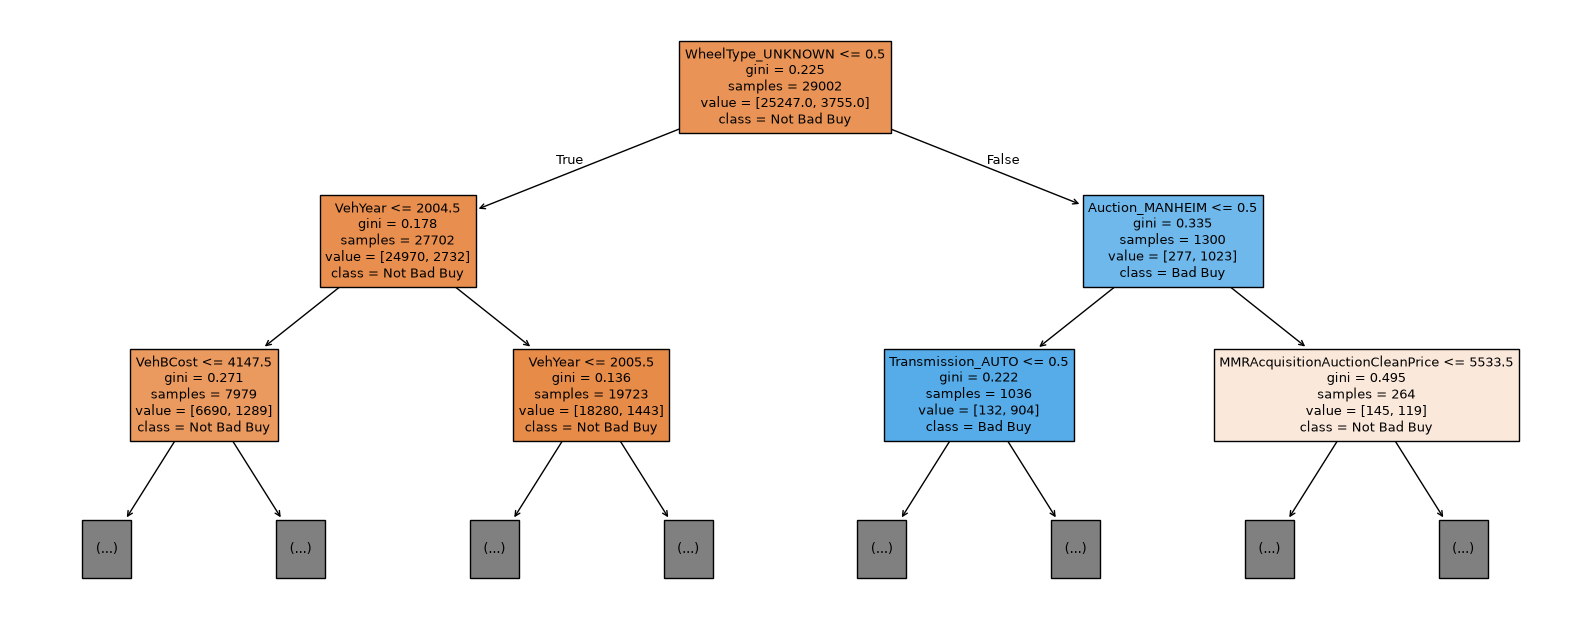

In [165]:
# Display the first two levels of the default decision tree
plt.figure(figsize=(20, 8))

plot_tree(
    model_default,
    feature_names=feature_names,
    class_names=["Not Bad Buy", "Bad Buy"],
    filled=True,
    max_depth=2,
    fontsize=9
)

plt.show()

In [166]:
# Function to display the most important features
def display_feature_importances(model, feature_names, features_to_display=5):
    importances = model.feature_importances_

    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)

    indices = indices[:features_to_display]

    for i in indices:
        print(feature_names[i], ":", importances[i])


In [167]:
# Display the five most important features
display_feature_importances(
    model_default,
    feature_names,
    features_to_display=5
)

WheelType_UNKNOWN : 0.17996699608597516
VehOdo : 0.07061515936045826
VehBCost : 0.06784471447716978
MMRCurrentRetailRatio : 0.055102054409467804
MMRAcquisitionAuctionAveragePrice : 0.04733111995764246


In [169]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters and search ranges
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20]
}

# Create and run GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_grid=param_grid,
    cv=10
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [170]:
# Display the optimal hyperparameters
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [171]:
# Refine the GridSearchCV search around the initial best parameters
param_grid_refined = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_search_refined = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_grid=param_grid_refined,
    cv=10
)

grid_search_refined.fit(X_train, y_train)

print("Best parameters:", grid_search_refined.best_params_)
print("Best cross-validation score:", grid_search_refined.best_score_)

Best parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation score: 0.8988692127565999


In [172]:
# Retrieve the optimal decision tree selected by GridSearchCV
model_tuned = grid_search_refined.best_estimator_

In [173]:
# Calculate training and test accuracy for the tuned decision tree
train_accuracy_tuned = model_tuned.score(X_train, y_train)
test_accuracy_tuned = model_tuned.score(X_test, y_test)

print("Training accuracy:", train_accuracy_tuned)
print("Test accuracy:", test_accuracy_tuned)

Training accuracy: 0.8994207296048549
Test accuracy: 0.8958165728077232


In [174]:
# Examine the size of the tuned decision tree
node_count_tuned = model_tuned.tree_.node_count
leaf_count_tuned = model_tuned.get_n_leaves()

print("Number of nodes:", node_count_tuned)
print("Number of rules:", leaf_count_tuned)

Number of nodes: 31
Number of rules: 16


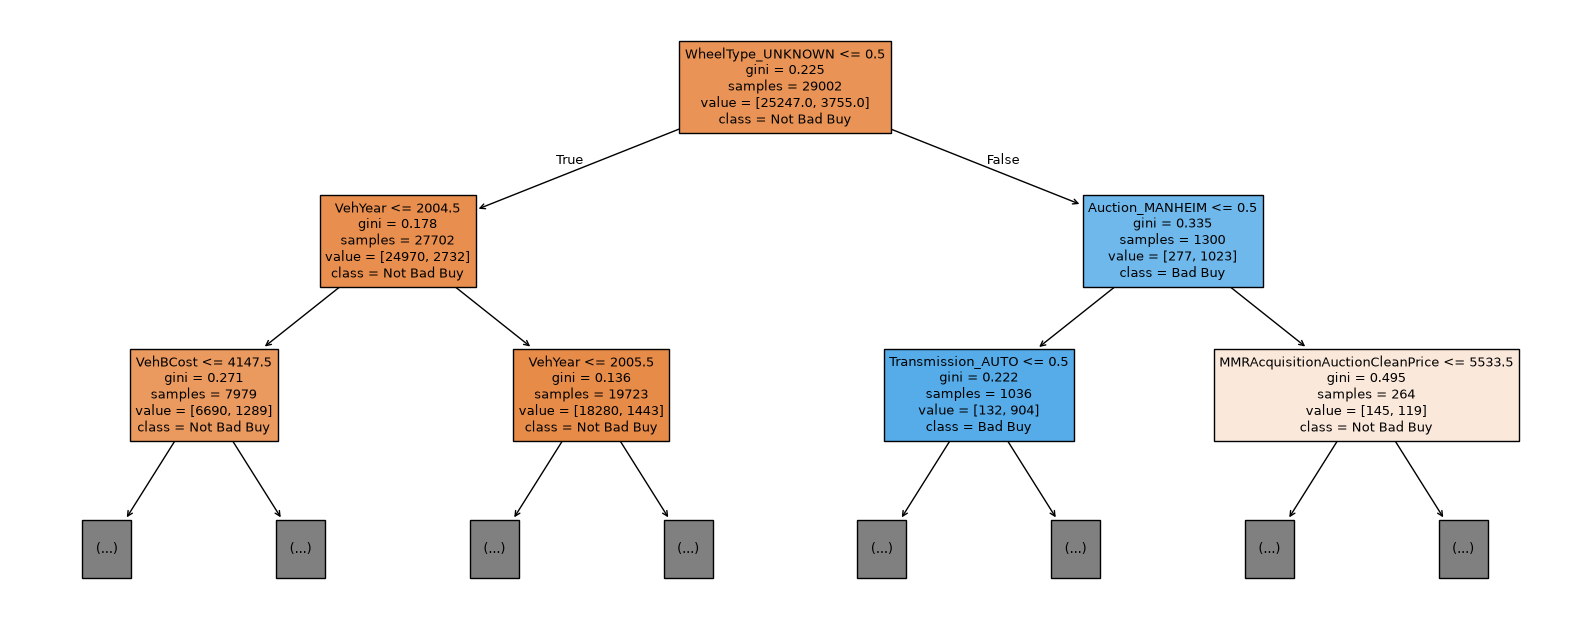

In [175]:
# Display the first two levels of the tuned decision tree
plt.figure(figsize=(20, 8))

plot_tree(
    model_tuned,
    feature_names=feature_names,
    class_names=["Not Bad Buy", "Bad Buy"],
    filled=True,
    max_depth=2,
    fontsize=9
)

plt.show()

In [176]:
# Display the five most important features of the tuned decision tree
display_feature_importances(
    model_tuned,
    feature_names,
    features_to_display=5
)

WheelType_UNKNOWN : 0.8027074936601063
VehYear : 0.0729223037489367
Auction_MANHEIM : 0.05108183435709802
VehBCost : 0.01628745944671066
MMRAcquisitionAuctionAveragePrice : 0.012081588503153088


In [181]:
# Calculate probability predictions for both decision trees
y_pred_proba_default = model_default.predict_proba(X_test)
y_pred_proba_tuned = model_tuned.predict_proba(X_test)

# Calculate ROC-AUC scores
roc_index_default = roc_auc_score(y_test, y_pred_proba_default[:, 1])
roc_index_tuned = roc_auc_score(y_test, y_pred_proba_tuned[:, 1])

print("ROC index on test for default model:", roc_index_default)
print("ROC index on test for tuned model:", roc_index_tuned)

ROC index on test for default model: 0.6162271386092008
ROC index on test for tuned model: 0.7321470763825902


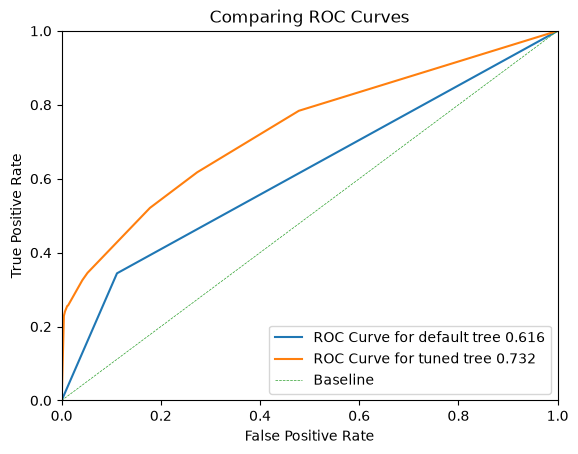

In [182]:
# Calculate false positive and true positive rates
fpr_default, tpr_default, thresholds_default = roc_curve(
    y_test, y_pred_proba_default[:, 1]
)

fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(
    y_test, y_pred_proba_tuned[:, 1]
)

# Plot ROC curves for both decision trees
plt.plot(
    fpr_default,
    tpr_default,
    label="ROC Curve for default tree {:.3f}".format(roc_index_default)
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label="ROC Curve for tuned tree {:.3f}".format(roc_index_tuned)
)

plt.plot(
    [0, 1],
    [0, 1],
    lw=0.5,
    label="Baseline",
    linestyle="--"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparing ROC Curves")
plt.legend()

plt.show()

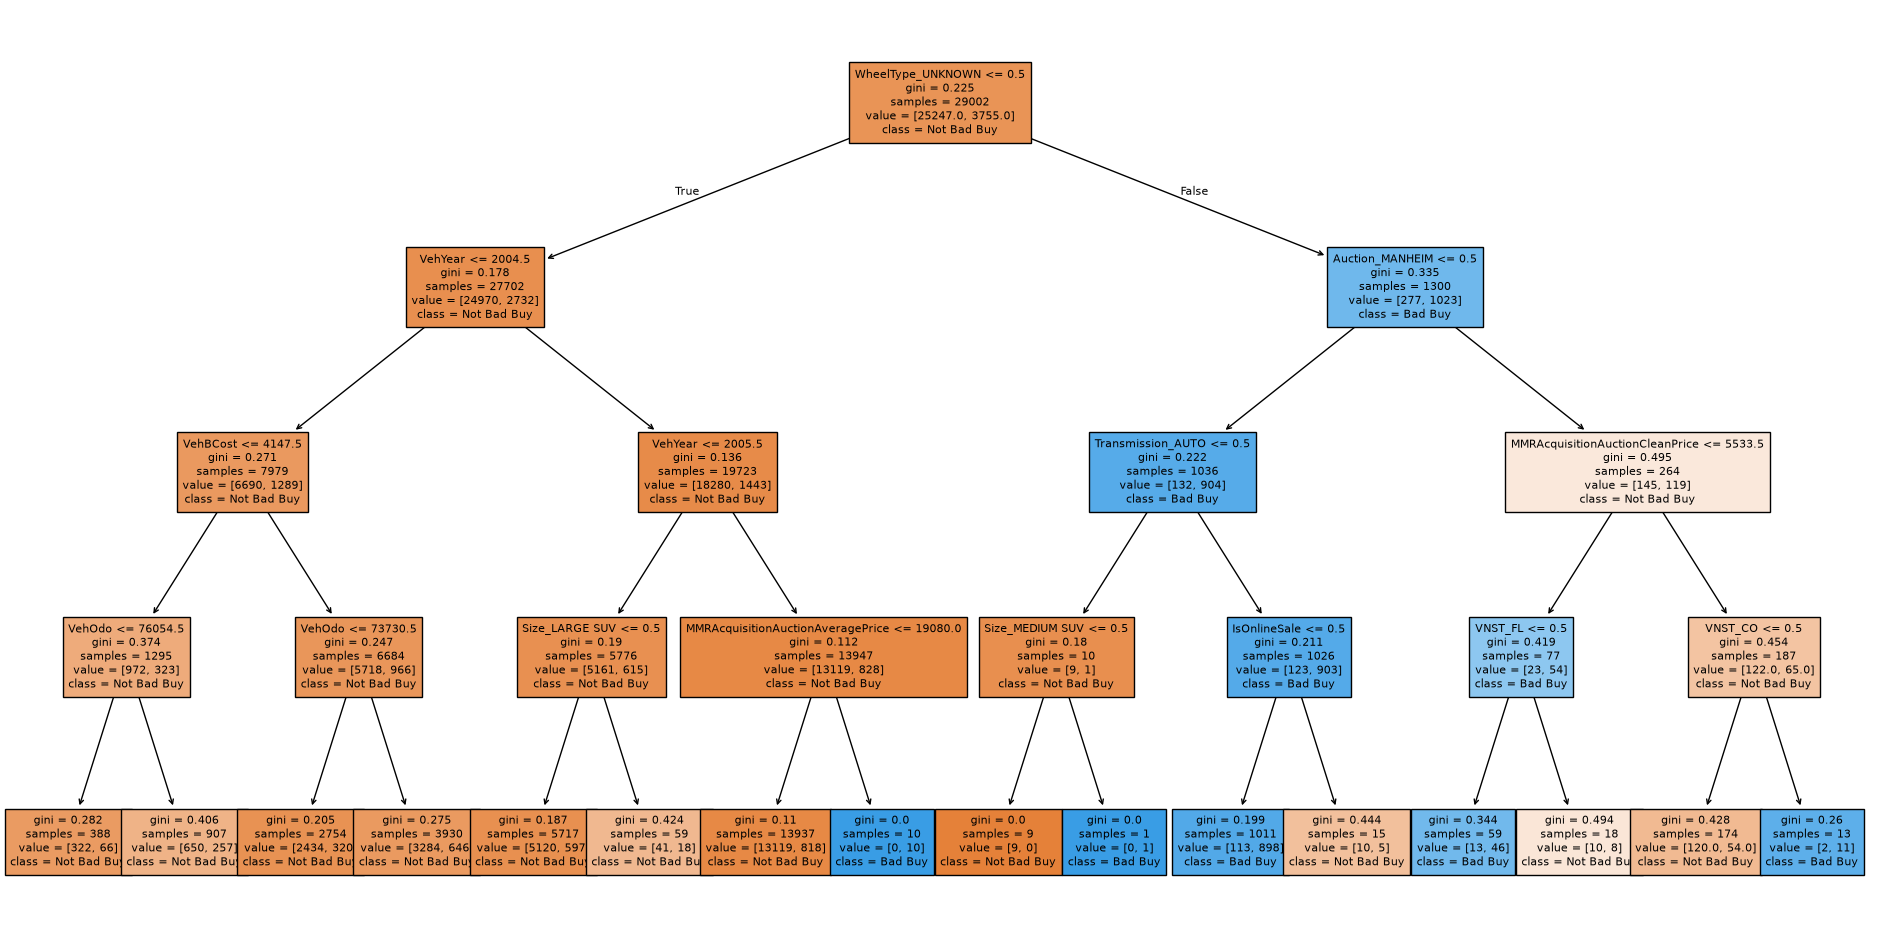

In [183]:
# Display the complete tuned decision tree
plt.figure(figsize=(24, 12))

plot_tree(
    model_tuned,
    feature_names=feature_names,
    class_names=["Not Bad Buy", "Bad Buy"],
    filled=True,
    fontsize=8
)

plt.show()

# Logistic Regression Modelling

In [185]:
# Initialise a StandardScaler object
scaler = StandardScaler()

In [190]:
# Display statistics before scaling
print("Before scaling")

for i in range(5):
    col = X_train[:, i]
    print(
        feature_names[i],
        "- min:", col.min(),
        "max:", col.max(),
        "mean:", round(col.mean(), 2),
        "std dev:", round(col.std(), 2)
    )

Before scaling
VehYear - min: 2001.0 max: 2010.0 mean: 2005.36 std dev: 1.73
VehOdo - min: 577.0 max: 480444.0 mean: 71324.5 std dev: 14759.61
MMRAcquisitionAuctionAveragePrice - min: 889.0 max: 33543.0 mean: 6203.04 std dev: 2380.31
MMRAcquisitionAuctionCleanPrice - min: 1240.0 max: 36701.0 mean: 7459.64 std dev: 2612.47
MMRAcquisitionRetailAveragePrice - min: 1543.0 max: 36726.0 mean: 8544.37 std dev: 3025.1


In [187]:
# Learn the mean and standard deviation from the training data
# and standardise the training data
X_train_scaled = scaler.fit_transform(X_train)

In [188]:
# Apply the training-data scaling to the test data
X_test_scaled = scaler.transform(X_test)

In [191]:
# Display statistics after scaling
print("After scaling")

for i in range(5):
    col = X_train_scaled[:, i]
    print(
        feature_names[i],
        "- min:", round(col.min(), 2),
        "max:", round(col.max(), 2),
        "mean:", round(col.mean(), 2),
        "std dev:", round(col.std(), 2)
    )

After scaling
VehYear - min: -2.52 max: 2.68 mean: 0.0 std dev: 1.0
VehOdo - min: -4.79 max: 27.72 mean: 0.0 std dev: 1.0
MMRAcquisitionAuctionAveragePrice - min: -2.23 max: 11.49 mean: 0.0 std dev: 1.0
MMRAcquisitionAuctionCleanPrice - min: -2.38 max: 11.19 mean: -0.0 std dev: 1.0
MMRAcquisitionRetailAveragePrice - min: -2.31 max: 9.32 mean: 0.0 std dev: 1.0


## Task 3.2 – Regression Modelling with GridSearchCV 

In [193]:
# Create the Logistic Regression model
log_reg = LogisticRegression(
    random_state=random_state,
    max_iter=1000
)

In [197]:
# Define hyperparameter and search range
param_grid_log = {
    "C": [pow(10, x) for x in range(-6, 4)]
}

print(param_grid_log)

{'C': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}


In [229]:
# Create GridSearchCV
grid_search_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    cv=10
)

# Fit using the standardised training data
grid_search_log.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-06, 1e-05, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

In [230]:
# Display the optimal parameter and cross-validation score
print("Best parameters:", grid_search_log.best_params_)
print("Best cross-validation score:", grid_search_log.best_score_)

Best parameters: {'C': 1}
Best cross-validation score: 0.897110746591544


In [231]:
# Report variables included in the logistic regression model
print("Number of variables:", len(feature_names))

for feature in feature_names:
    print(feature)

Number of variables: 120
VehYear
VehOdo
MMRAcquisitionAuctionAveragePrice
MMRAcquisitionAuctionCleanPrice
MMRAcquisitionRetailAveragePrice
MMRAcquisitonRetailCleanPrice
MMRCurrentAuctionAveragePrice
MMRCurrentAuctionCleanPrice
MMRCurrentRetailAveragePrice
MMRCurrentRetailCleanPrice
MMRCurrentRetailRatio
VehBCost
IsOnlineSale
WarrantyCost
Auction_ADESA
Auction_MANHEIM
Auction_OTHER
Make_ACURA
Make_BUICK
Make_CADILLAC
Make_CHEVROLET
Make_CHRYSLER
Make_DODGE
Make_FORD
Make_GMC
Make_HONDA
Make_HYUNDAI
Make_INFINITI
Make_ISUZU
Make_JEEP
Make_KIA
Make_LEXUS
Make_LINCOLN
Make_MAZDA
Make_MERCURY
Make_MINI
Make_MITSUBISHI
Make_NISSAN
Make_OLDSMOBILE
Make_PONTIAC
Make_SATURN
Make_SCION
Make_SUBARU
Make_SUZUKI
Make_TOYOTA
Make_VOLKSWAGEN
Make_VOLVO
Color_BEIGE
Color_BLACK
Color_BLUE
Color_BROWN
Color_GOLD
Color_GREEN
Color_GREY
Color_MAROON
Color_ORANGE
Color_OTHER
Color_PURPLE
Color_RED
Color_SILVER
Color_UNKNOWN
Color_WHITE
Color_YELLOW
Transmission_AUTO
Transmission_MANUAL
Transmission_UNKNOWN

In [232]:
# Retrieve the best logistic regression model
model_log_tuned = grid_search_log.best_estimator_

# Retrieve the model coefficients
coef = model_log_tuned.coef_[0]

# Rank variables by absolute coefficient magnitude
indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

# Select the five most important variables
indices = indices[:5]

# Display the five most important variables and coefficients
for i in indices:
    print(feature_names[i], ":", coef[i])

MMRAcquisitionAuctionAveragePrice : -1.145093029280855
MMRAcquisitionRetailAveragePrice : 0.8864173175827059
MMRCurrentRetailCleanPrice : -0.858726967955804
MMRCurrentAuctionAveragePrice : 0.754924897732235
WheelType_UNKNOWN : 0.7210543613005851


In [233]:
# Calculate classification accuracy for the tuned logistic regression model
train_accuracy_log = model_log_tuned.score(X_train_scaled, y_train)
test_accuracy_log = model_log_tuned.score(X_test_scaled, y_test)

print("Training accuracy:", train_accuracy_log)
print("Test accuracy:", test_accuracy_log)

Training accuracy: 0.8974208675263775
Test accuracy: 0.8939662107803701


In [234]:
# Calculate the difference between training and test accuracy
accuracy_gap_log = train_accuracy_log - test_accuracy_log

print("Accuracy difference:", accuracy_gap_log)

Accuracy difference: 0.003454656746007423


In [235]:
# Calculate the difference between training and test accuracy
accuracy_gap_log = train_accuracy_log - test_accuracy_log

print("Training accuracy:", train_accuracy_log)
print("Test accuracy:", test_accuracy_log)
print("Accuracy difference:", accuracy_gap_log)
print("Accuracy difference (%):", accuracy_gap_log * 100)

Training accuracy: 0.8974208675263775
Test accuracy: 0.8939662107803701
Accuracy difference: 0.003454656746007423
Accuracy difference (%): 0.3454656746007423


## Minimum Variable Set Regression Model

In [237]:
# Create Logistic Regression estimator for feature selection
log_reg_rfe = LogisticRegression(
    random_state=random_state,
    max_iter=1000
)

In [238]:
# Perform Recursive Feature Elimination with Cross-Validation
rfecv = RFECV(
    estimator=log_reg_rfe,
    step=1,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

In [239]:
# Identify the optimal feature subset
rfecv.fit(X_train_scaled, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegre...ndom_state=10)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",10
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'accuracy'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation 

In [240]:
print("Original number of variables:", X_train_scaled.shape[1])
print("Optimal number of variables:", rfecv.n_features_)

Original number of variables: 120
Optimal number of variables: 42


In [241]:
# Identify variables retained by RFECV
selected_features = np.array(feature_names)[rfecv.support_]

print("Selected variables:")
for feature in selected_features:
    print(feature)

Selected variables:
VehYear
VehOdo
MMRAcquisitionAuctionAveragePrice
MMRAcquisitionAuctionCleanPrice
MMRAcquisitionRetailAveragePrice
MMRAcquisitonRetailCleanPrice
MMRCurrentAuctionAveragePrice
MMRCurrentAuctionCleanPrice
MMRCurrentRetailAveragePrice
MMRCurrentRetailCleanPrice
MMRCurrentRetailRatio
VehBCost
WarrantyCost
Auction_MANHEIM
Make_BUICK
Make_CHEVROLET
Make_MITSUBISHI
Make_PONTIAC
Make_SUZUKI
Make_VOLVO
Color_OTHER
Transmission_UNKNOWN
WheelType_Alloy
WheelType_Covers
WheelType_UNKNOWN
Size_COMPACT
Size_LARGE
Size_LARGE SUV
Size_MEDIUM SUV
Size_UNKNOWN
Size_VAN
VNST_FL
VNST_GA
VNST_ID
VNST_KY
VNST_NC
VNST_NY
VNST_OR
VNST_PA
VNST_TN
VNST_UT
VNST_WA


In [242]:
# Create reduced training and test datasets using RFECV-selected features
X_train_reduced = rfecv.transform(X_train_scaled)
X_test_reduced = rfecv.transform(X_test_scaled)

print("Reduced training shape:", X_train_reduced.shape)
print("Reduced test shape:", X_test_reduced.shape)

Reduced training shape: (29002, 42)
Reduced test shape: (12430, 42)


In [243]:
# Define hyperparameter search range
param_grid_reduced = {
    "C": [pow(10, x) for x in range(-6, 4)]
}

# Tune Logistic Regression using the reduced feature set
grid_search_reduced = GridSearchCV(
    estimator=LogisticRegression(
        random_state=random_state,
        max_iter=1000
    ),
    param_grid=param_grid_reduced,
    cv=10
)

# Fit the reduced model
grid_search_reduced.fit(X_train_reduced, y_train)

# Display optimal parameter and cross-validation score
print("Best parameters:", grid_search_reduced.best_params_)
print("Best cross-validation score:", grid_search_reduced.best_score_)

Best parameters: {'C': 0.1}
Best cross-validation score: 0.8972486657395192


In [244]:
# Retrieve the best reduced logistic regression model
model_log_reduced = grid_search_reduced.best_estimator_

# Calculate training and test accuracy
train_accuracy_reduced = model_log_reduced.score(
    X_train_reduced, y_train
)

test_accuracy_reduced = model_log_reduced.score(
    X_test_reduced, y_test
)

print("Training accuracy:", train_accuracy_reduced)
print("Test accuracy:", test_accuracy_reduced)

Training accuracy: 0.8973519067650507
Test accuracy: 0.8942880128720837


In [245]:
# Calculate the difference between training and test accuracy
accuracy_gap_reduced = (
    train_accuracy_reduced - test_accuracy_reduced
)

print("Accuracy difference:", accuracy_gap_reduced)
print("Accuracy difference (%):", accuracy_gap_reduced * 100)

Accuracy difference: 0.003063893892967018
Accuracy difference (%): 0.3063893892967018


In [248]:
# Generate probability predictions for both regression models
y_pred_proba_log = model_log_tuned.predict_proba(X_test_scaled)
y_pred_proba_reduced = model_log_reduced.predict_proba(X_test_reduced)

# Calculate ROC-AUC scores
roc_index_log = roc_auc_score(
    y_test,
    y_pred_proba_log[:, 1]
)

roc_index_reduced = roc_auc_score(
    y_test,
    y_pred_proba_reduced[:, 1]
)

print("ROC index on test for full regression model:", roc_index_log)
print("ROC index on test for reduced regression model:", roc_index_reduced)

ROC index on test for full regression model: 0.762966670876339
ROC index on test for reduced regression model: 0.7629486458249618


In [250]:
# Calculate ROC curve coordinates
fpr_log, tpr_log, thresholds_log = roc_curve(
    y_test,
    y_pred_proba_log[:, 1]
)

fpr_reduced, tpr_reduced, thresholds_reduced = roc_curve(
    y_test,
    y_pred_proba_reduced[:, 1]
)

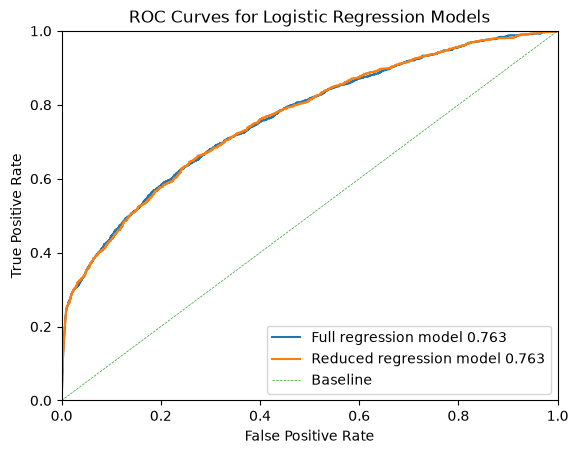

In [251]:
# Plot ROC curves
plt.plot(
    fpr_log,
    tpr_log,
    label="Full regression model {:.3f}".format(roc_index_log)
)

plt.plot(
    fpr_reduced,
    tpr_reduced,
    label="Reduced regression model {:.3f}".format(roc_index_reduced)
)

# Random-classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    lw=0.5,
    label="Baseline",
    linestyle="--"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression Models")
plt.legend()

plt.show()

In [252]:
# Retrieve coefficients from the reduced logistic regression model
coef_reduced = model_log_reduced.coef_[0]

# Sort coefficients from highest positive to lowest
indices_positive = np.argsort(coef_reduced)[::-1]

# Display the ten strongest positive predictors of Bad Buy
print("Strongest characteristics associated with Bad Buy:")

for i in indices_positive[:10]:
    print(selected_features[i], ":", coef_reduced[i])

Strongest characteristics associated with Bad Buy:
WheelType_UNKNOWN : 0.7580438534890516
MMRAcquisitionRetailAveragePrice : 0.595349328769196
MMRCurrentAuctionAveragePrice : 0.4468894064151494
MMRCurrentRetailAveragePrice : 0.1538424396187385
MMRAcquisitonRetailCleanPrice : 0.11373653681099787
VehOdo : 0.08532361889773005
Size_MEDIUM SUV : 0.07252968672429343
VNST_PA : 0.06249838537925876
Make_SUZUKI : 0.06112883449551038
WarrantyCost : 0.048623622274056644


In [253]:
# Export the processed dataset to CSV
df_processed.to_csv("df_processed.csv", index=False)

print("df_processed.csv exported successfully")

df_processed.csv exported successfully


In [254]:
import os
print(os.getcwd())

C:\Users\anant\IFQ580


In [255]:
import os
print(os.path.exists("df_processed.csv"))

True


In [256]:
# Convert X_train and X_test to DataFrames with feature names
X_train_export = pd.DataFrame(X_train, columns=feature_names)
X_test_export = pd.DataFrame(X_test, columns=feature_names)

# Convert y_train and y_test to DataFrames
y_train_export = pd.DataFrame(
    np.array(y_train).reshape(-1, 1),
    columns=["IsBadBuy"]
)

y_test_export = pd.DataFrame(
    np.array(y_test).reshape(-1, 1),
    columns=["IsBadBuy"]
)

# Export all four datasets to CSV
X_train_export.to_csv("X_train.csv", index=False)
X_test_export.to_csv("X_test.csv", index=False)
y_train_export.to_csv("y_train.csv", index=False)
y_test_export.to_csv("y_test.csv", index=False)

print("X_train.csv exported successfully")
print("X_test.csv exported successfully")
print("y_train.csv exported successfully")
print("y_test.csv exported successfully")

X_train.csv exported successfully
X_test.csv exported successfully
y_train.csv exported successfully
y_test.csv exported successfully


# Task 4 - Neural Networks

In [257]:
## Task 4 - Neural Networks ##

# Import libraries #
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import(
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [258]:
 Load exact training and testing datasets from Tasks 2 and 3. #

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

In [259]:
# Standadise the predictor variables. #
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [260]:
# Task 4.2 - Neural Network - All Predictor Variables. #

# Create neural network model.
nn_full = MLPClassifier(
    random_state=42,
    max_iter=500
)

In [261]:
# Define hyperparameters to test. #

param_grid_full = {
    'hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 25),
        (100, 50)
    ],
    'activation' : ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init' : [0.001, 0.01]
} 

In [262]:
# Prepare the grid search with cross validation. #

grid_full = GridSearchCV(
    estimator=nn_full,
    param_grid=param_grid_full,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1
)

In [263]:
# Train the model with the training data. #

grid_full.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [264]:
# Print the parameters. #

best_nn_full = grid_full.best_estimator_

print("Best parameters: ")
print(grid_full.best_params_)

print(f"Best cross-validation ROC-AUC: {grid_full.best_score_:.4f}")

Best parameters: 
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Best cross-validation ROC-AUC: 0.7104


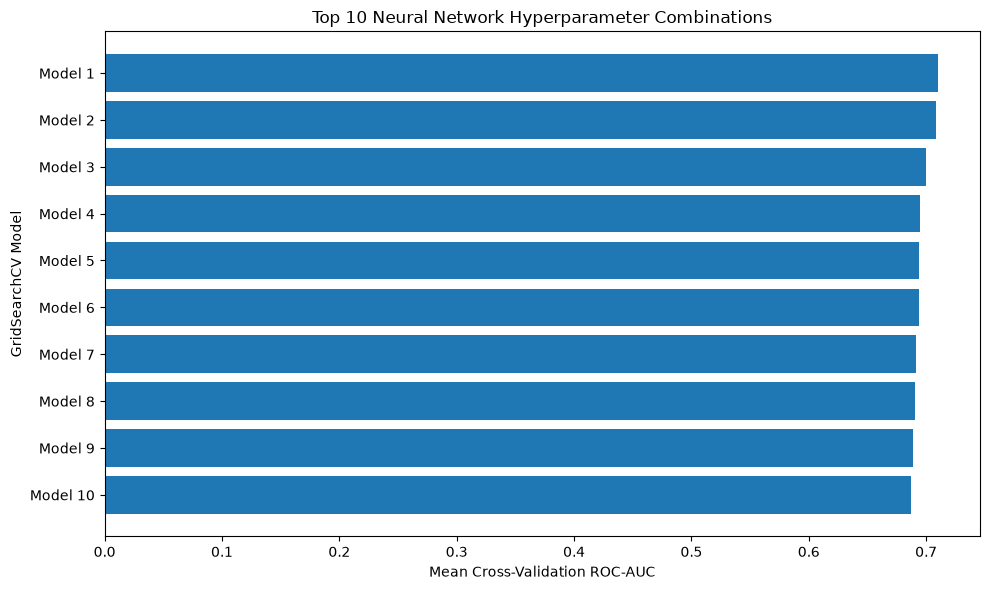

In [265]:
# Plot the 10 best GridSearchCV parameter combinations #

cv_results = pd.DataFrame(grid_full.cv_results_)

top_10 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .copy()
)

top_10['Model'] = [
    f"Model {i}" for i in range(1, len(top_10) + 1)
]

plt.figure(figsize=(10, 6))

plt.barh(
    top_10['Model'][::-1],
    top_10['mean_test_score'][::-1]
)

plt.xlabel('Mean Cross-Validation ROC-AUC')
plt.ylabel('GridSearchCV Model')
plt.title('Top 10 Neural Network Hyperparameter Combinations')

plt.tight_layout()
plt.show()

In [266]:
# Evaluate training and test performance. #

y_train_pred = best_nn_full.predict(X_train_scaled) # Predictions
y_test_pred = best_nn_full.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred) # Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Training accuracy: 0.9076
Test accuracy: 0.8879


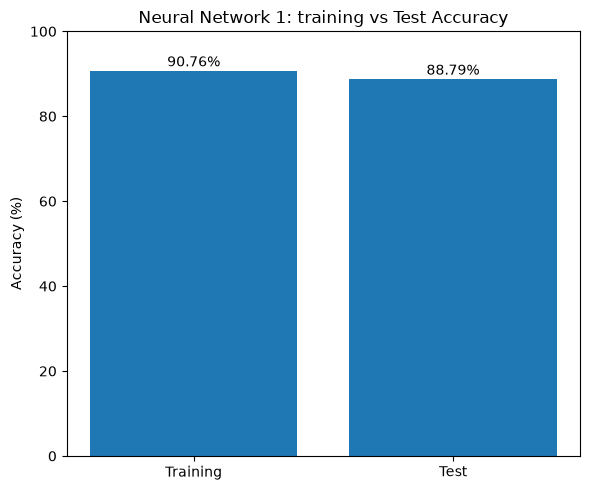

In [267]:
# Plot training and test accuracy. #
accuracy_values = [
    train_accuracy * 100,
    test_accuracy * 100
]

plt.figure(figsize=(6, 5))

bars = plt.bar(
    ['Training', 'Test'],
    accuracy_values
)

plt.ylabel('Accuracy (%)')
plt.title('Neural Network 1: training vs Test Accuracy')
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [268]:
# Iterations and convergence. #

print("Iterations: ", best_nn_full.n_iter_)
print("final loss: ", best_nn_full.loss_)

Iterations:  96
final loss:  0.27969415848779816


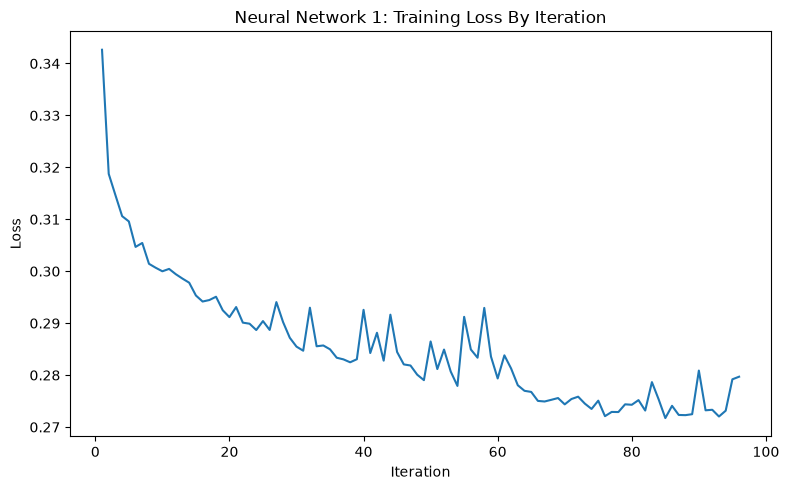

In [269]:
# Plot training loss across iterations. #
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(best_nn_full.loss_curve_) + 1),
    best_nn_full.loss_curve_
)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Neural Network 1: Training Loss By Iteration')

plt.tight_layout()
plt.show()

In [270]:
# ROC-AUC Curve. #

#Probability of IsBadBuy = 1
y_test_prob = best_nn_full.predict_proba(X_test_scaled)[:, 1]

#ROC-AUC
auc_full = roc_auc_score(y_test, y_test_prob)

print(f"Test ROC-AUC: {auc_full:.4f}")

Test ROC-AUC: 0.7266


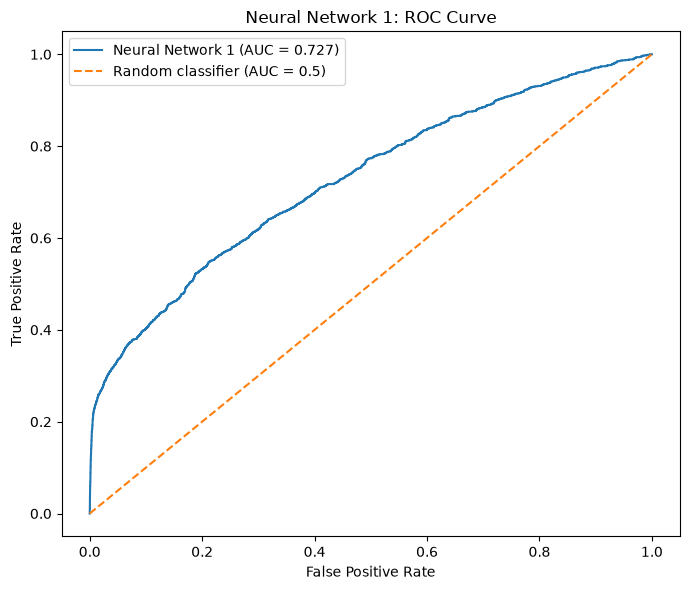

In [271]:
# Calculate ROC curve #

fpr_full, tpr_full, threshholds_full = roc_curve(
    y_test,
    y_test_prob
)

#Plot ROC curve #
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_full,
    tpr_full,
    label=f'Neural Network 1 (AUC = {auc_full:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier (AUC = 0.5)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network 1: ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [272]:
# 10 fold cross validation ROC-AUC scores. #
print(f"Best cross-validation ROC-AUC: {grid_full.best_score_:.4f}")

Best cross-validation ROC-AUC: 0.7104


In [273]:
## Task 4.3 - Decision Tree Selected Features. ##

# Features selected using Decision tree feature importance. #
selected_features = [
    'WheelType_UNKNOWN',
    'VehYear',
    'Auction_MANHEIM',
    'VehBCost',
    'MMRAcquisitionAuctionAveragePrice'
]

# Create reduced training and test datasets. #
X_train_reduced = X_train[selected_features].copy()
X_test_reduced = X_test[selected_features].copy()

# Check dimensions of reduced datasets. #
print("Reduced training data:", X_train_reduced.shape)
print("Reduced test data:", X_test_reduced.shape)

X_train_reduced.head()

Reduced training data: (29002, 5)
Reduced test data: (12430, 5)


,WheelType_UNKNOWN,VehYear,Auction_MANHEIM,VehBCost,MMRAcquisitionAuctionAveragePrice
0,False,2003.0,False,5210.0,3425.0
1,False,2002.0,True,5960.0,4650.0
2,False,2003.0,True,6140.0,3819.0
3,True,2003.0,False,4850.0,2774.0
4,False,2007.0,True,6250.0,6944.0


In [274]:
# Save reduced training and test datasets as CSV files. #
X_train_reduced.to_csv('X_train_reduced.csv', index=False)
X_test_reduced.to_csv('X_test_reduced.csv', index=False)

In [275]:
# Standardise the reduced predictor variables. #
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler_reduced.transform(
    X_test_reduced
)

# Check dimensions #
print("Scaled reduced training data:", X_train_reduced_scaled.shape)
print("Scaled reduced test data:", X_test_reduced_scaled.shape)

Scaled reduced training data: (29002, 5)
Scaled reduced test data: (12430, 5)


In [276]:
# Neural Network 2 - Decision Tree selected variables. #

# Create neural network model.
nn_reduced = MLPClassifier(
    random_state=42,
    max_iter=500
)

In [277]:
# Define hyperparameters to test Neural Network 2. #

param_grid_reduced = {
    'hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 25),
        (100, 50)
    ],
    'activation' : ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init' : [0.001, 0.01]
} 

In [278]:
# Prepare the grid search with cross validation for Neural Network 2. #

grid_reduced = GridSearchCV(
    estimator=nn_reduced,
    param_grid=param_grid_reduced,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1
)

In [279]:
# Train the model with the reduced training data. #

grid_reduced.fit(
    X_train_reduced_scaled, 
    y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [280]:
# Print the parameters. #

best_nn_reduced = grid_reduced.best_estimator_

print("Best parameters: ")
print(grid_reduced.best_params_)

print(f"Best cross-validation ROC-AUC: {grid_reduced.best_score_:.4f}")

Best parameters: 
{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
Best cross-validation ROC-AUC: 0.7517


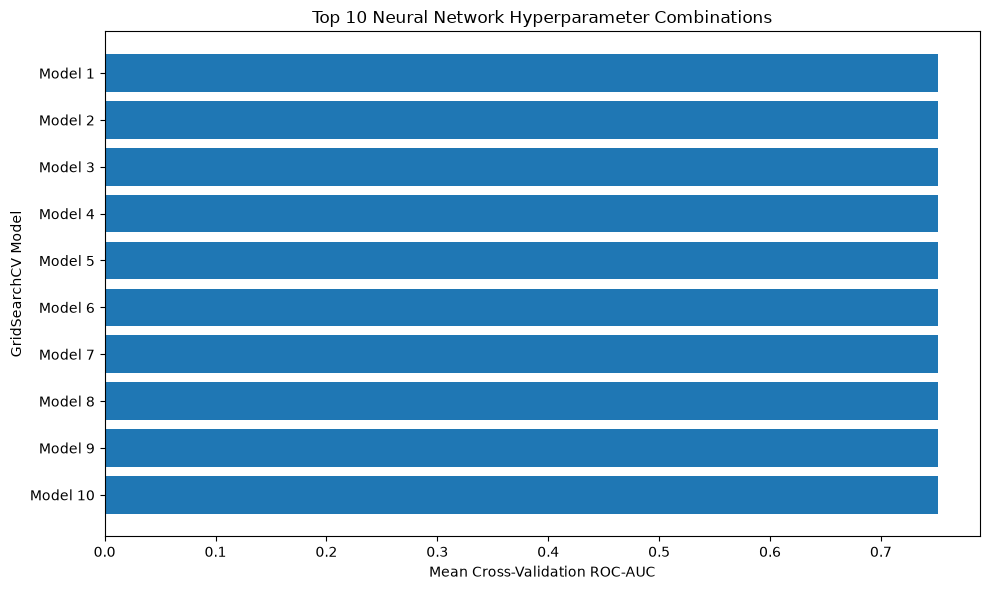

In [281]:
# Plot the 10 best GridSearchCV parameter combinations for NN2 #

cv_results = pd.DataFrame(grid_reduced.cv_results_)

top_10 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .copy()
)

top_10['Model'] = [
    f"Model {i}" for i in range(1, len(top_10) + 1)
]

plt.figure(figsize=(10, 6))

plt.barh(
    top_10['Model'][::-1],
    top_10['mean_test_score'][::-1]
)

plt.xlabel('Mean Cross-Validation ROC-AUC')
plt.ylabel('GridSearchCV Model')
plt.title('Top 10 Neural Network Hyperparameter Combinations')

plt.tight_layout()
plt.show()

In [282]:
# Evaluate NN2 training and test performance. #

y_train_pred = best_nn_reduced.predict(X_train_reduced_scaled) # Predictions
y_test_pred = best_nn_reduced.predict(X_test_reduced_scaled)

train_reduced_accuracy = accuracy_score(y_train, y_train_pred) # Accuracy
test_reduced_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_reduced_accuracy:.4f}")
print(f"Test accuracy: {test_reduced_accuracy:.4f}")


Training accuracy: 0.8978
Test accuracy: 0.8958


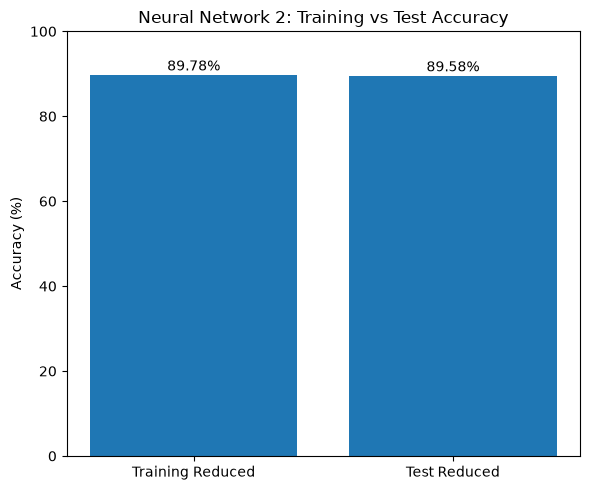

In [283]:
# Plot NN2 training and test accuracy. #
accuracy_values = [
    train_reduced_accuracy * 100,
    test_reduced_accuracy * 100
]

plt.figure(figsize=(6, 5))

bars = plt.bar(
    ['Training Reduced', 'Test Reduced'],
    accuracy_values
)

plt.ylabel('Accuracy (%)')
plt.title('Neural Network 2: Training vs Test Accuracy')
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()


In [284]:
# NN2 Iterations and convergence. #

print("Iterations: ", best_nn_reduced.n_iter_)
print("final loss: ", best_nn_reduced.loss_)


Iterations:  39
final loss:  0.3114856888441988


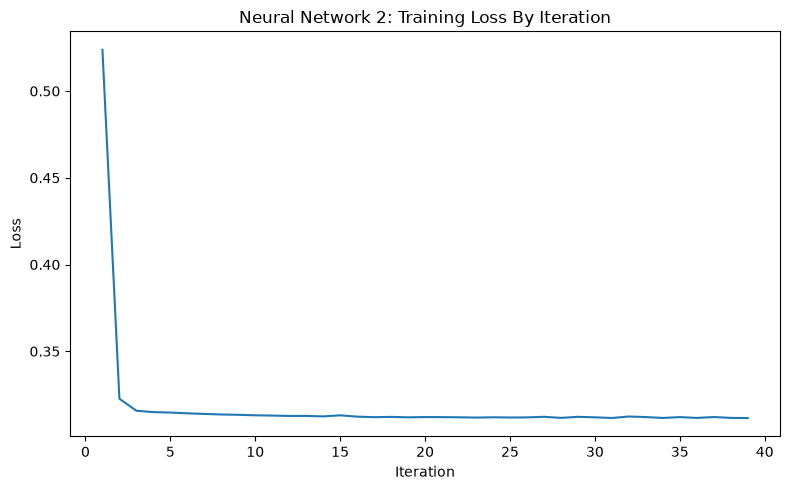

In [285]:
# Plot NN2 training loss across iterations. #
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(best_nn_reduced.loss_curve_) + 1),
    best_nn_reduced.loss_curve_
)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Neural Network 2: Training Loss By Iteration')

plt.tight_layout()
plt.show()

In [286]:
# ROC-AUC Curve NN2. #

#Probability of IsBadBuy = 1
y_test_prob = best_nn_reduced.predict_proba(X_test_reduced_scaled)[:, 1]

#ROC-AUC
auc_reduced = roc_auc_score(y_test, y_test_prob)

print(f"Test ROC-AUC: {auc_reduced:.4f}")

Test ROC-AUC: 0.7563


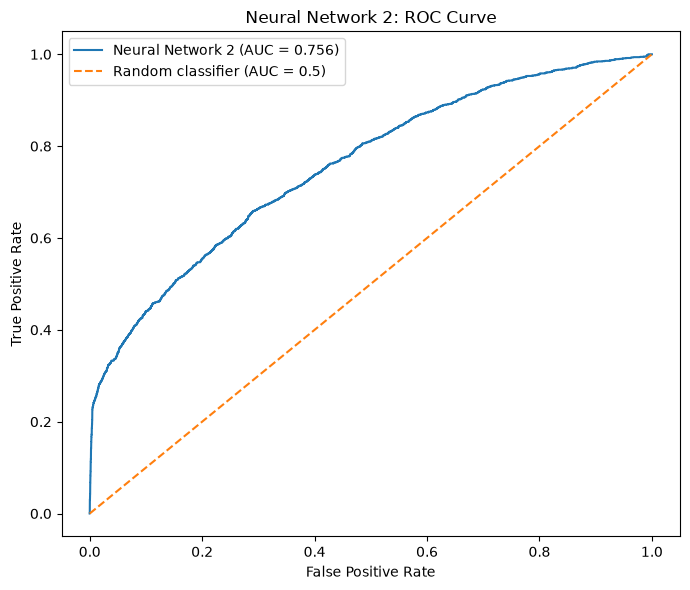

In [287]:
# Calculate NN2 ROC curve #

fpr_reduced, tpr_reduced, threshholds_reduced = roc_curve(
    y_test,
    y_test_prob
)

#Plot ROC curve #
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_reduced,
    tpr_reduced,
    label=f'Neural Network 2 (AUC = {auc_reduced:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier (AUC = 0.5)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network 2: ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [288]:
# 10 fold cross validation ROC-AUC scores NN2. #
print(f"Best cross-validation ROC-AUC: {grid_reduced.best_score_:.4f}")

Best cross-validation ROC-AUC: 0.7517


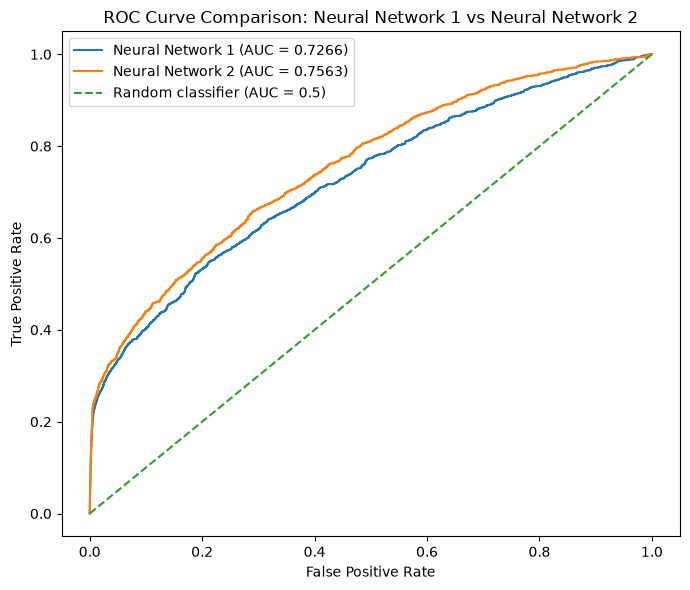

NN1 Test ROC-AUC: 0.7266
NN2 Test ROC-AUC: 0.7563


In [289]:
# Comparison of NN1 and NN2 ROC curves. #

# NN1 - full feature model #
y_test_prob_full = best_nn_full.predict_proba(
    X_test_scaled
)[:, 1]

fpr_full, tpr_full, _ = roc_curve(
    y_test, 
    y_test_prob_full
)

auc_full = roc_auc_score(
    y_test, 
    y_test_prob_full
)

# NN2 - reduced feature model #
y_test_prob_reduced = best_nn_reduced.predict_proba(
    X_test_reduced_scaled
)[:, 1]

fpr_reduced, tpr_reduced, _ = roc_curve(
    y_test, 
    y_test_prob_reduced
)

auc_reduced = roc_auc_score(
    y_test, 
    y_test_prob_reduced
)

# Plot ROC curves for both NN1 and NN2. #

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_full,
    tpr_full,
    label=f'Neural Network 1 (AUC = {auc_full:.4f})'
)


plt.plot(
    fpr_reduced,
    tpr_reduced,
    label=f'Neural Network 2 (AUC = {auc_reduced:.4f})'
)

# Random classifier line #
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier (AUC = 0.5)'
)


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Neural Network 1 vs Neural Network 2')
plt.legend()

plt.tight_layout()
plt.show()

# Print comparison scores for both models #
print(f"NN1 Test ROC-AUC: {auc_full:.4f}")
print(f"NN2 Test ROC-AUC: {auc_reduced:.4f}")